# Import Libraries

In [152]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib

from statsmodels.graphics.mosaicplot import mosaic

from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,train_test_split

from sklearn.metrics import f1_score,precision_score,confusion_matrix,accuracy_score,classification_report,roc_curve,roc_auc_score
from sklearn.metrics import precision_recall_curve,average_precision_score,root_mean_squared_error,r2_score,mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [153]:
df = pd.read_csv("dataset/disease_prediction.csv")

# EDA

In [154]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [155]:
df.tail()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
995,996,24,Male,105,237,86,86,30.9,69,Yes,Yes,Medium,No,No
996,997,40,Male,120,219,133,72,34.3,92,Yes,Yes,Medium,No,No
997,998,44,Female,114,273,114,74,36.0,76,No,No,Low,No,Yes
998,999,31,Male,95,231,130,72,28.2,81,Yes,Yes,Medium,Yes,No
999,1000,83,Male,109,256,103,86,30.3,64,Yes,Yes,High,No,Yes


In [156]:
df.shape

(1000, 14)

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [158]:
df.isnull().sum()

patient_id             0
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

In [159]:
df.duplicated().any()

np.False_

## Columns Distribution

In [160]:
df.columns

Index(['patient_id', 'age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl',
       'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'smoking',
       'alcohol_consumption', 'physical_activity', 'family_history',
       'disease'],
      dtype='object')

#### Patient ID

In [161]:
df['patient_id'].duplicated().any()

np.False_

#### Age

In [162]:
df['age'].unique()

array([32, 31, 45, 75, 53, 66, 76, 64, 28, 52, 22, 58, 51, 69, 24, 26, 19,
       73, 40, 38, 78, 43, 20, 25, 83, 34, 30, 77, 61, 49, 79, 18, 80, 85,
       23, 56, 44, 60, 72, 57, 42, 62, 36, 27, 46, 82, 74, 37, 67, 21, 59,
       65, 48, 47, 33, 54, 84, 81, 55, 63, 71, 68, 70, 50, 41, 35, 29, 39])

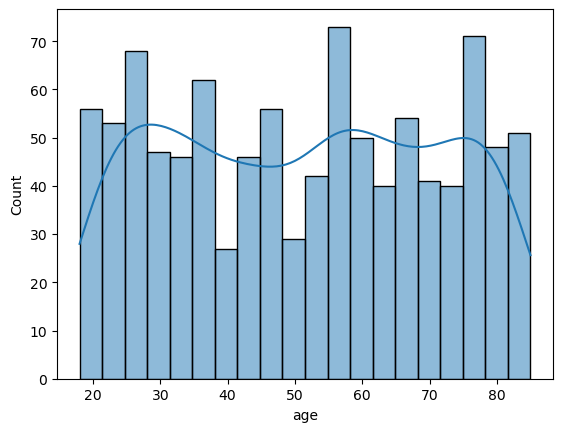

In [163]:
sns.histplot(data=df,x='age',bins=20,kde=True)
plt.show()

#### Gender

In [164]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

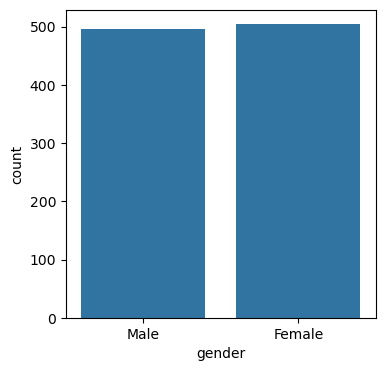

In [165]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='gender')
plt.show()

#### Glucose mg dl

In [166]:
df['glucose_mg_dl'].unique()

array([101, 124,  57,  69, 107, 151,  56,  97,  60, 128, 100, 130, 144,
        55,  92, 129, 111,  84, 103, 112,  82,  90, 116,  74, 113,  86,
       125,  83,  73,  76,  81, 133,  99,  64, 121, 120, 102,  88,  89,
        87,  96,  79, 143, 105, 108, 117, 138, 106, 148, 122, 110,  98,
        77,  70,  80, 119,  94, 146, 161,  67,  91, 142,  95, 136, 147,
       132,  62,  71, 109, 150,  65, 127, 166, 134,  85, 131, 123,  66,
       152,  53, 114,  61, 139,  68, 165, 158, 167,  72, 118,  59, 170,
       115, 155,  58,  93, 135,  31, 156, 184, 137,  78, 104, 183,  54,
       173,  47, 141,  63, 182, 149, 126, 179, 140,  51,  30, 145,  75,
       176, 153, 163,  39,  45,  52,  34,  33, 164,  49,  48,  50,  36,
        42])

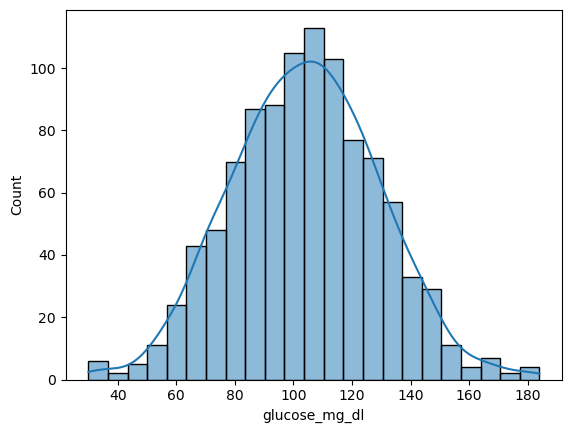

In [167]:
sns.histplot(data=df,x='glucose_mg_dl',kde=True)
plt.show()

#### Cholesterol mg dl

In [168]:
df['cholesterol_mg_dl'].unique()

array([235, 191, 141, 268, 163, 209, 156, 150, 222, 176, 165, 224, 105,
       201, 246, 181, 210, 203, 133, 208, 266, 213, 173, 219, 160, 182,
       162, 248, 174, 167, 216, 230, 190, 180, 128, 280, 149, 172, 275,
       256, 212, 295, 245, 239, 231, 262, 226, 205, 296, 223, 157, 238,
       272, 200, 252, 270, 225, 170, 187, 198, 233, 145, 277, 247, 186,
       179, 175, 221, 217, 199, 244, 138, 307, 178, 158, 283, 103, 153,
       166, 147, 218, 214, 188, 251, 136, 255, 207, 267, 192, 184, 154,
       237, 242, 211, 206, 152, 241, 183, 234, 236, 229, 195, 197, 249,
       257, 273, 110, 265, 232, 276, 258, 215, 220, 161, 107, 168, 228,
       271, 259, 204, 292, 177, 285, 185, 113, 227, 196, 202, 169, 261,
       123, 134, 146, 279, 254, 315,  89, 189, 112, 306, 194, 290, 171,
       159, 135, 151, 193, 250, 284, 243, 253, 288, 108, 155, 143,  93,
       263, 148, 142, 300, 278, 269, 291, 309, 339, 144, 122, 260, 264,
       130, 282, 114, 240, 129, 293, 164, 140, 115, 320, 301, 29

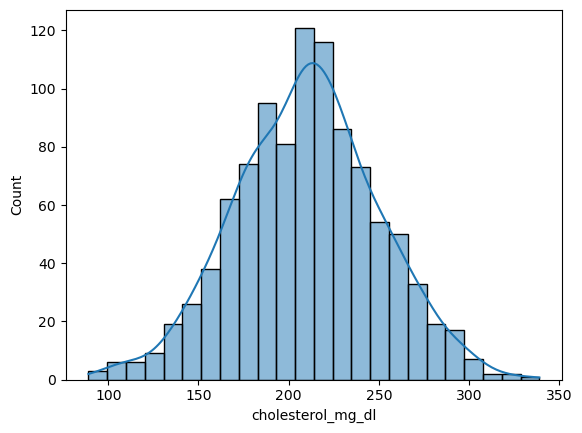

In [169]:
sns.histplot(data=df,x='cholesterol_mg_dl',kde=True)
plt.show()

#### Systolic bp

In [170]:
df['systolic_bp'].unique()

array([152, 134, 114, 120, 131, 105, 128, 112, 118, 119, 103, 113, 139,
       130, 132, 124,  99, 115, 148, 101, 129, 136, 110, 151, 133,  97,
       135, 126, 144, 140, 116, 123, 125,  89, 121, 111, 158, 157, 147,
       104, 127, 142,  93, 108,  83, 159, 109, 138,  92,  95, 150, 117,
       162, 106, 145, 107, 149, 122, 143, 137, 146, 163,  85,  90, 153,
        96,  72, 102, 166, 141, 100, 156, 171, 154, 155,  73,  98, 165,
       160,  94,  84,  87, 195,  88,  86,  91,  80,  79, 175, 161,  67,
       170, 168, 177])

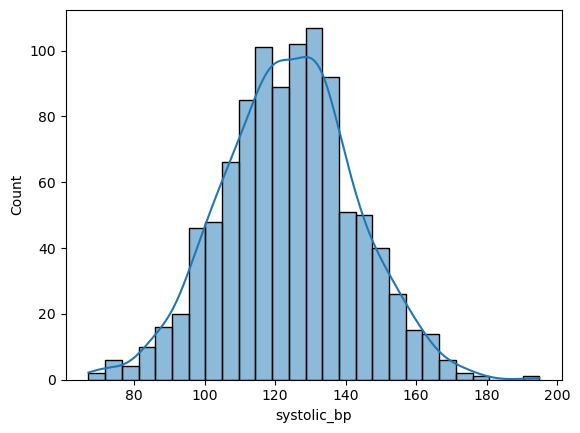

In [171]:
sns.histplot(data=df,x='systolic_bp',kde=True)
plt.show()

#### Diastolic bp

In [172]:
df['diastolic_bp'].unique()

array([ 79,  77,  71,  82,  75,  90,  89,  85,  96,  76,  78,  67, 100,
        93,  87,  66,  74,  65,  84,  72,  81,  73,  92, 105,  69,  94,
        49,  83,  80,  88,  91,  60,  70,  98,  61, 101, 112,  68,  57,
        63,  86,  55,  97, 107,  95, 102,  99,  62,  58,  54,  64, 111,
        52, 103, 113,  51])

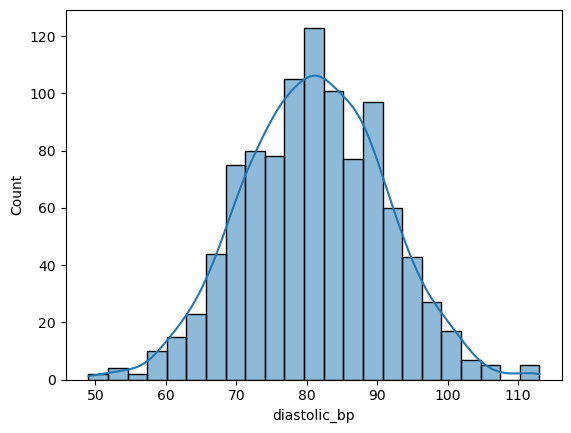

In [173]:
sns.histplot(data=df,x='diastolic_bp',kde=True)
plt.show()

#### BMI

In [174]:
df['bmi'].unique()

array([28.5, 33.9, 27.2, 21.5, 23.3, 23. , 27. , 25.4, 27.7, 31.2, 23.6,
       25.6, 25.8, 26.5, 22. , 27.5, 24.3, 27.3, 25. , 30. , 21. , 20.7,
       30.1, 35.3, 31.8, 24.8, 27.4, 29.1, 28.4, 27.1, 26.3, 19.1, 28.9,
       22.1, 29.4, 22.4, 36.7, 36.6, 28.2, 24.7, 33.2, 27.8, 21.9, 32.4,
       27.6, 25.9, 28.6, 33.3, 36.9, 22.2, 17.4, 26. , 26.6, 36.3, 21.2,
       17.5, 19.5, 25.7, 25.5, 22.5, 34.2, 22.8, 26.4, 21.6, 22.7, 30.2,
       28. , 32. , 26.1, 29.2, 29.8, 34. , 38.9, 23.1, 30.7, 19.9, 24.2,
       16. , 34.3, 21.4, 38.8, 22.9, 26.9, 23.8, 25.1, 37.5, 23.9, 23.2,
       23.4, 29. , 32.9, 19.2, 20.9, 29.3, 22.6, 18.1, 35. , 34.7, 26.2,
       31.7, 23.7, 31. , 29.6, 30.6, 31.5, 38. , 24.5, 20.5, 30.9, 31.1,
       28.8, 18. , 21.8, 34.4, 32.1, 27.9, 31.4, 21.3, 24.9, 24.1, 20.1,
       33.4, 32.5, 36.1, 32.6, 25.2, 34.6, 18.4, 33.7, 29.9, 29.5, 26.7,
       22.3, 28.1, 20.6, 26.8, 34.1, 30.4, 29.7, 18.5, 35.5, 20.3, 30.8,
       25.3, 17.6, 28.7, 31.9, 20. , 17. , 16.1, 17

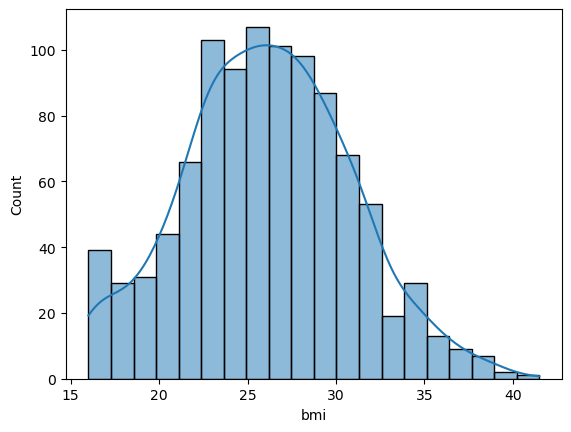

In [175]:
sns.histplot(data=df,x='bmi',kde=True)
plt.show()

#### Heart Rate

In [176]:
df['heart_rate'].unique()

array([ 73,  71,  79,  61,  63,  77,  86,  82,  85,  89,  91,  70,  81,
       100,  83,  97,  76,  72,  78,  68,  94, 103,  84, 114,  57,  65,
        69,  80,  96,  74,  67,  88,  55,  62,  75,  87,  90,  53,  59,
        92,  64,  93,  66, 102,  51,  47,  56,  95,  54,  98,  50,  58,
        60, 101,  99,  49, 107,  52])

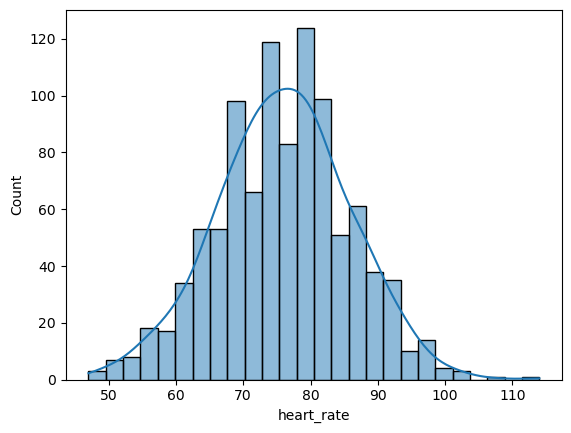

In [177]:
sns.histplot(data=df,x='heart_rate',kde=True)
plt.show()

#### Smoking

In [178]:
df['smoking'].unique()

array(['No', 'Yes'], dtype=object)

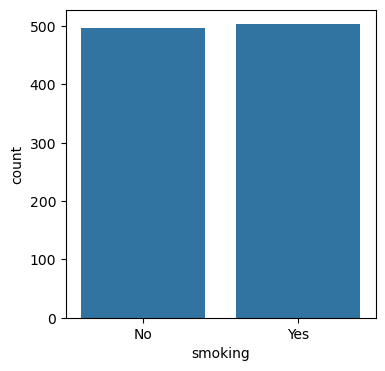

In [179]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='smoking')
plt.show()

#### Alcohol Consumption

In [180]:
df['alcohol_consumption'].unique()

array(['Yes', 'No'], dtype=object)

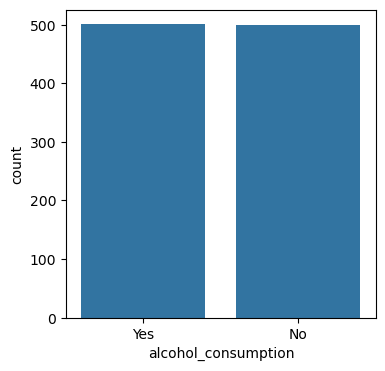

In [181]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='alcohol_consumption')
plt.show()

#### Physical Activity

In [182]:
df['physical_activity'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

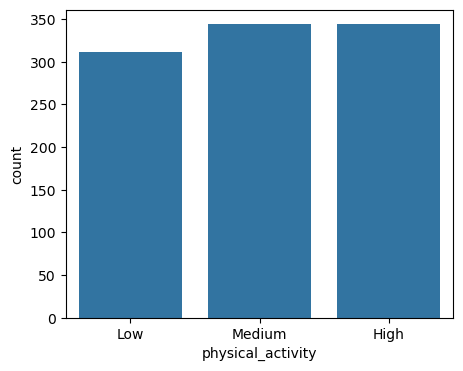

In [183]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x='physical_activity')
plt.show()

#### Family History

In [184]:
df['family_history'].unique()

array(['Yes', 'No'], dtype=object)

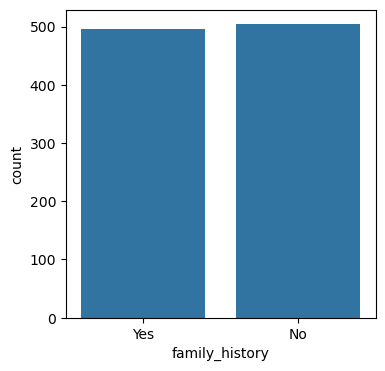

In [185]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='family_history')
plt.show()

#### Disease

In [186]:
df['disease'].unique()

array(['Yes', 'No'], dtype=object)

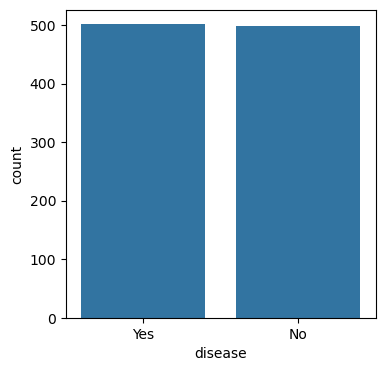

In [187]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='disease')
plt.show()

## Check Distribution of Input Features with Output Feature

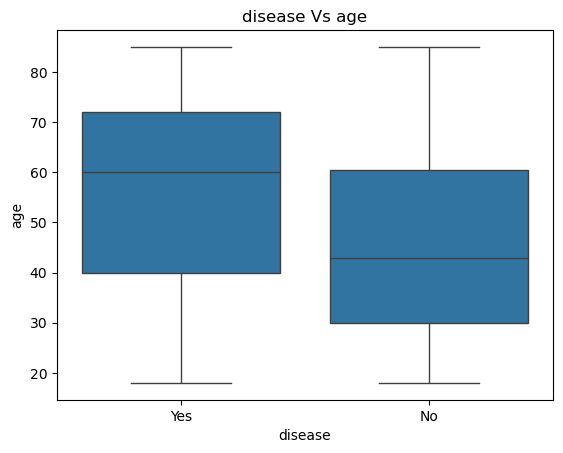

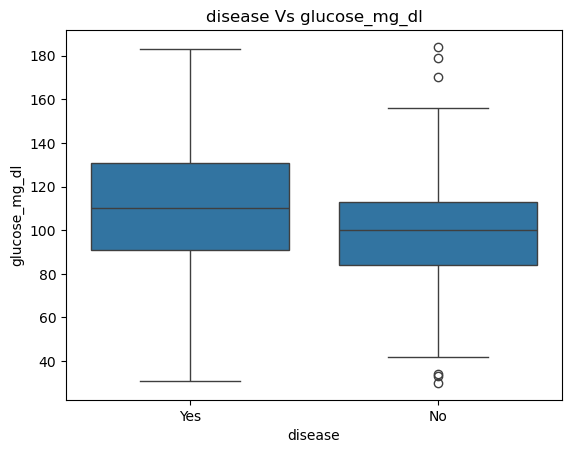

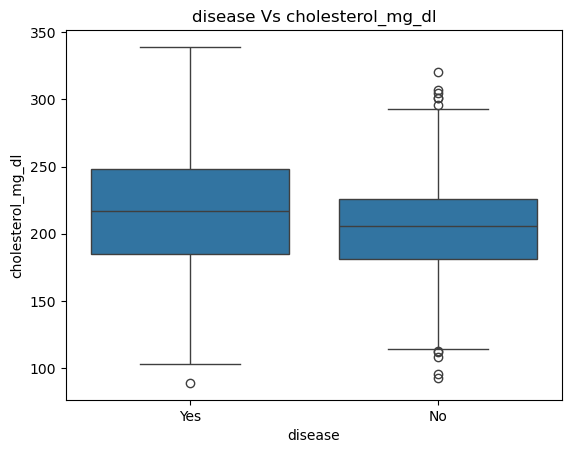

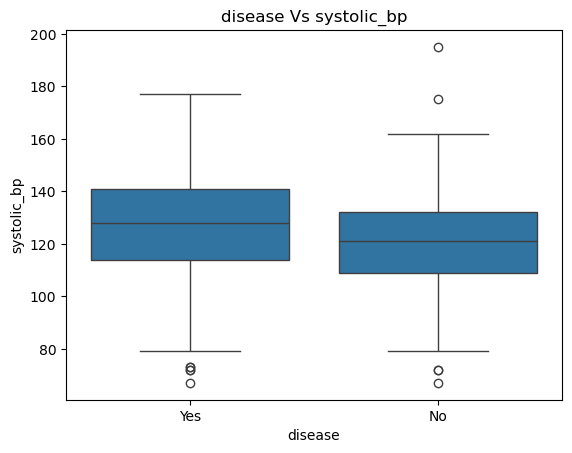

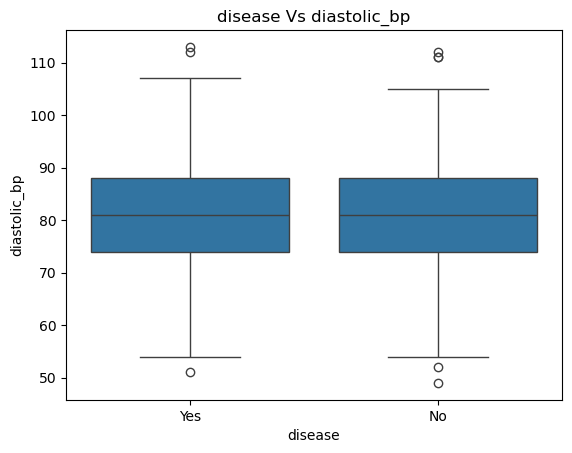

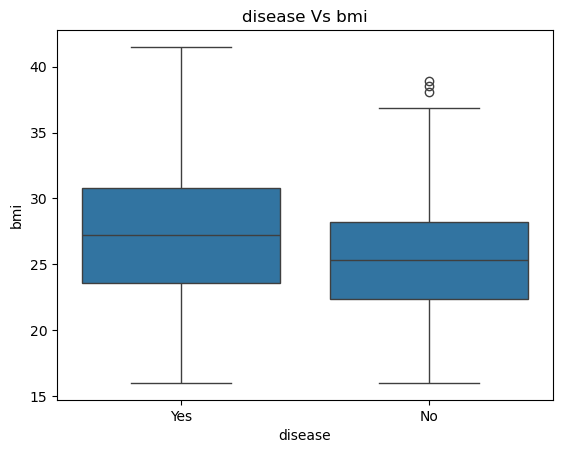

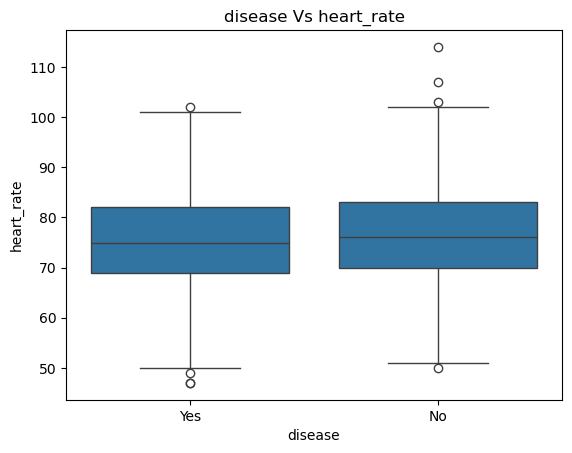

In [188]:
num_cols = ['age','glucose_mg_dl','cholesterol_mg_dl','systolic_bp','diastolic_bp','bmi','heart_rate']
for col in num_cols:
    sns.boxplot(data=df,x='disease',y=col)
    plt.title(f"disease Vs {col}")
    plt.show()

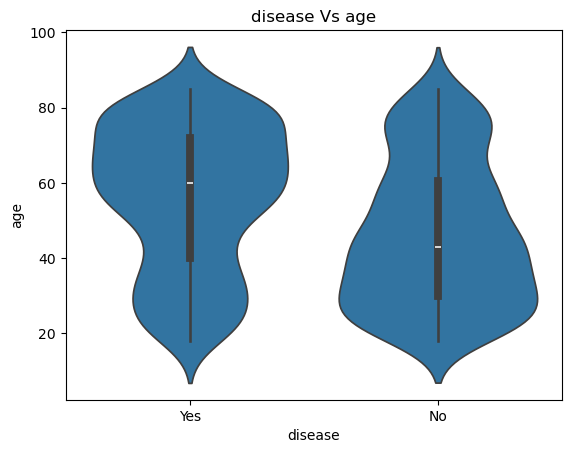

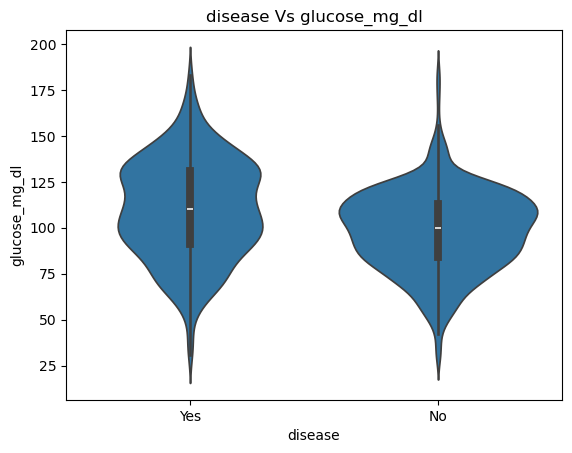

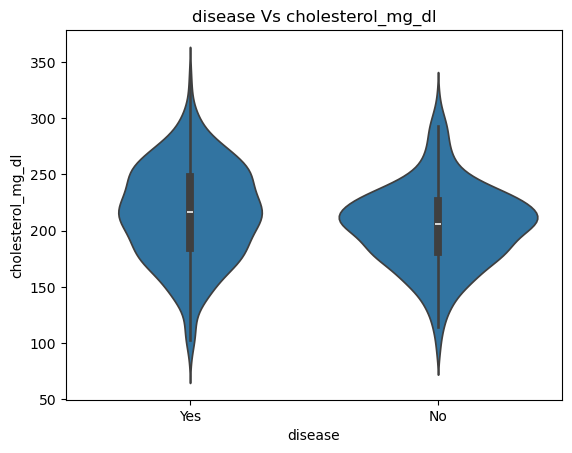

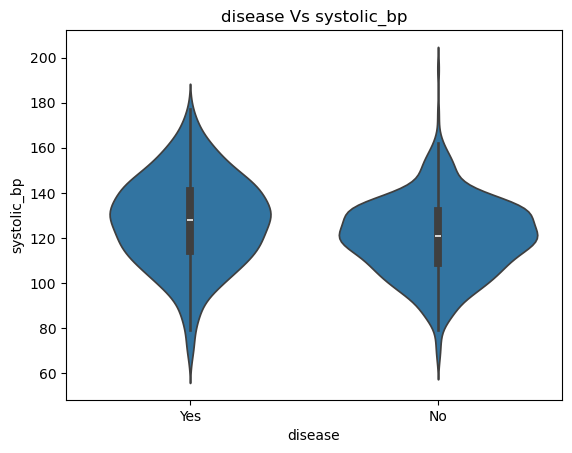

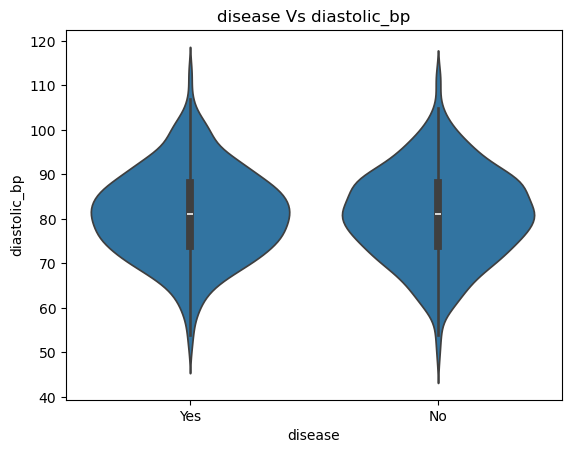

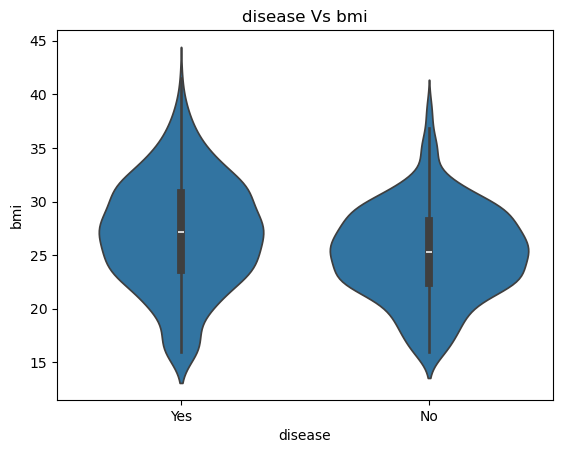

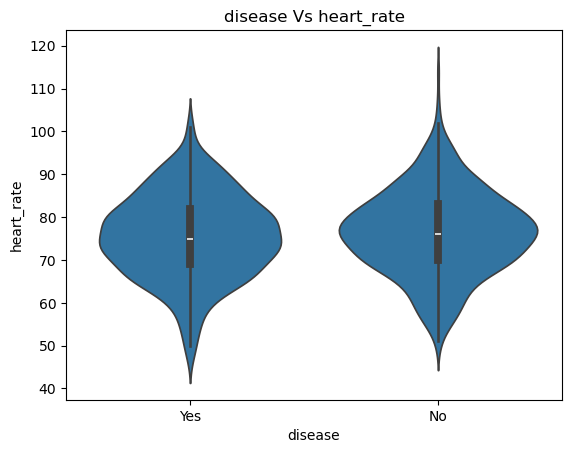

In [189]:
num_cols = ['age','glucose_mg_dl','cholesterol_mg_dl','systolic_bp','diastolic_bp','bmi','heart_rate']
for col in num_cols:
    sns.violinplot(data=df,x='disease',y=col)
    plt.title(f"disease Vs {col}")
    plt.show()

## Check Distribution of Input Features with Output Feature

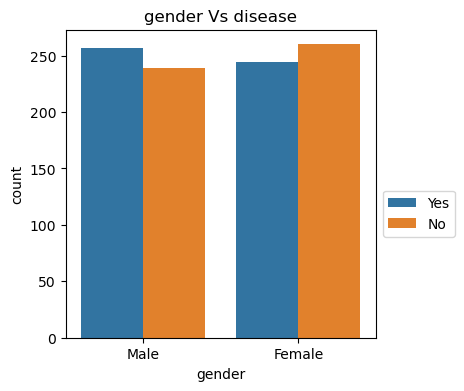

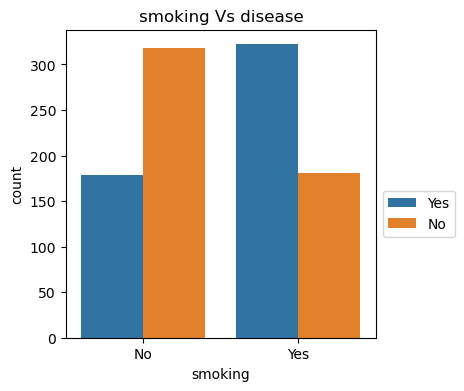

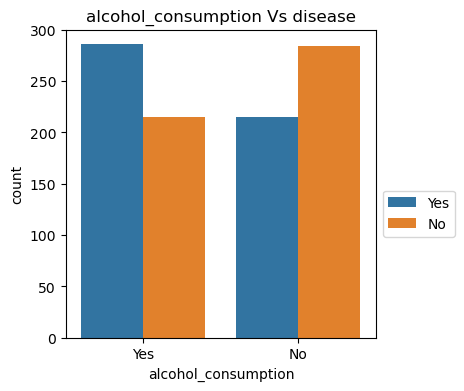

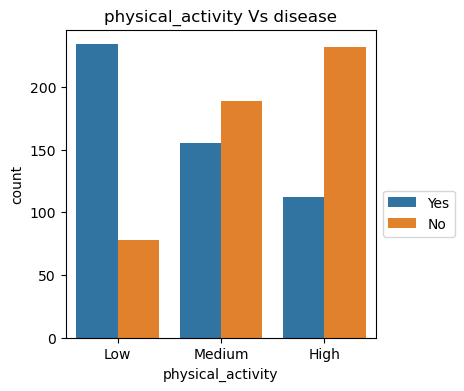

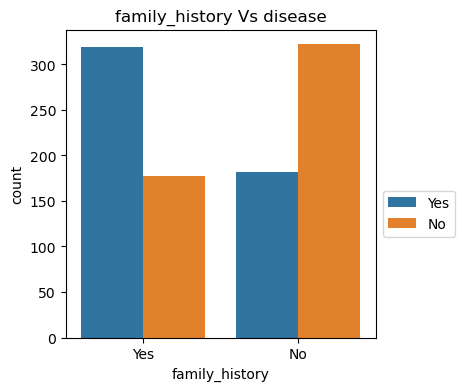

In [190]:
# categorical features
cat_features = ['gender','smoking','alcohol_consumption','physical_activity','family_history']
for col in cat_features:
    plt.figure(figsize=(4,4))
    sns.countplot(data=df,x=col,hue='disease')
    plt.title(f"{col} Vs disease")
    plt.legend(bbox_to_anchor=(1, 0.5))
    plt.show()

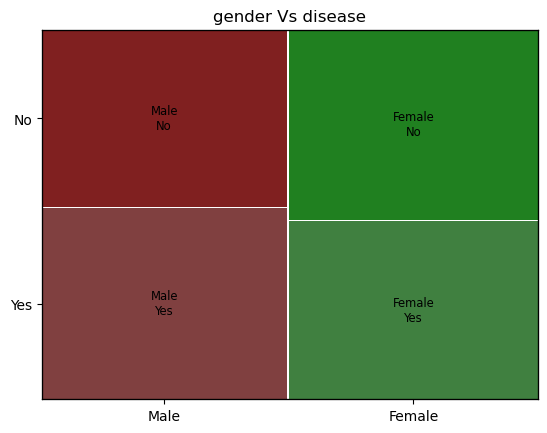

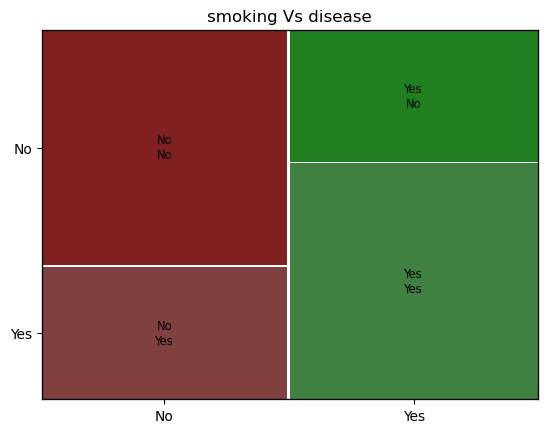

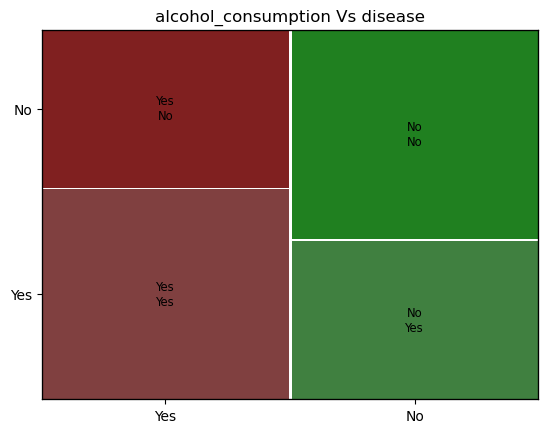

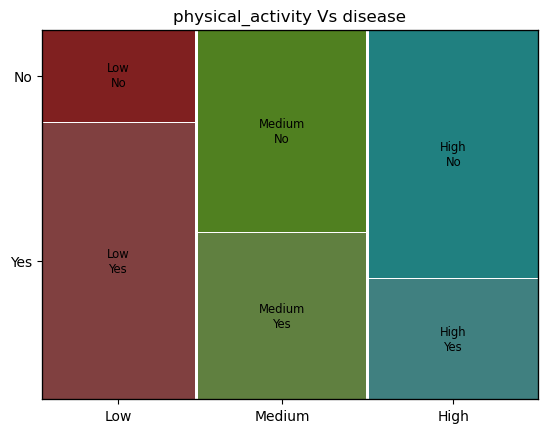

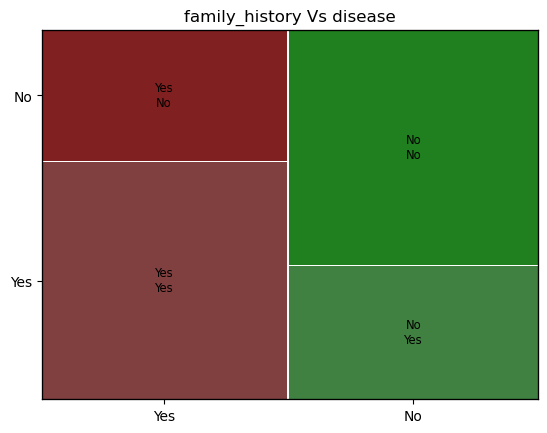

In [191]:
# categorical features

cat_features = ['gender','smoking','alcohol_consumption','physical_activity','family_history']

for col in cat_features:
    mosaic(data=df,index=[col, "disease"],title=f"{col} Vs disease")

In [192]:
# FEATURE ENGINEERING

# Feature Extraction

In [193]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


* No any Feature Extraction

### CHECK THE CORELATION OF THE DATASET 

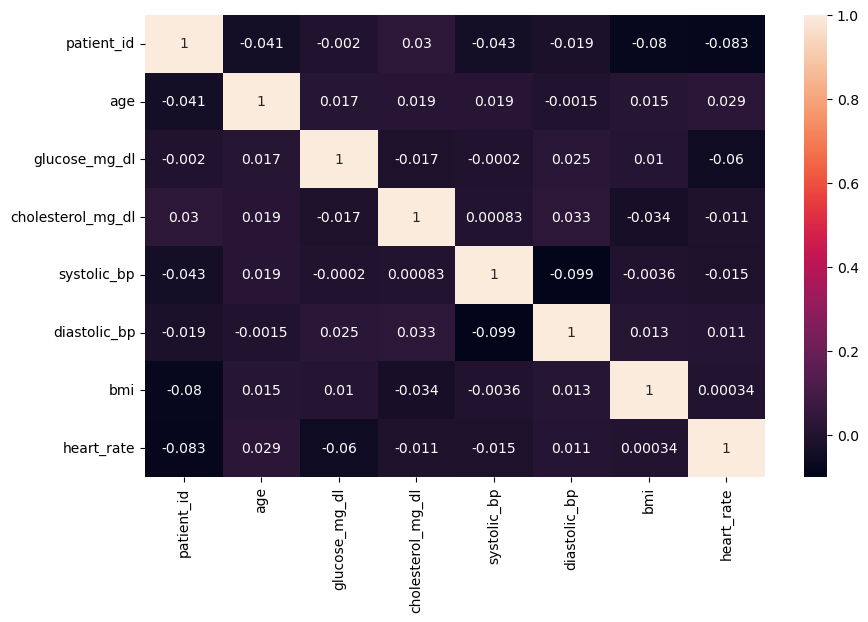

In [194]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

# MAKING DISEASE PREDICTION MODEL

## Split I/O Feature

In [195]:
df.columns

Index(['patient_id', 'age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl',
       'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'smoking',
       'alcohol_consumption', 'physical_activity', 'family_history',
       'disease'],
      dtype='object')

In [196]:
# Drop these two features ('heart_rate' and 'diastolic_bp') because no any kind of distribution with output feature ('disease')
X = df[[
        'age','gender','glucose_mg_dl','cholesterol_mg_dl','systolic_bp','smoking',
        'bmi','alcohol_consumption','physical_activity','family_history'
       ]]
y = df['disease']

## Train-Test-Split

In [197]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### GROUP FEATURES

In [198]:
ohe_feature = ['gender']
oe_features = ['physical_activity']
be_features = ['smoking','alcohol_consumption','family_history']
num_cols = ['age','glucose_mg_dl','bmi','cholesterol_mg_dl','systolic_bp']

## BUNDLE INTO THE COLUMNS TRANSOFMER

In [199]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first')
features_order = [['Low','Medium','High']]
oe = OrdinalEncoder(categories=features_order)
be = OrdinalEncoder(categories=[['No','Yes']]*len(be_features))

In [200]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe_feature',ohe,ohe_feature),
        ('cat_oe_features',oe,oe_features),
        ('cat_bin_features',be,be_features),
        ('num_cols',StandardScaler(),num_cols)
    ]
)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe_feature',ohe,ohe_feature),
        ('cat_oe_features',oe,oe_features),
        ('cat_bin_features',be,be_features)
    ]
)

## MAKING PIPELINES FOR MODELS

In [201]:
lrn_model_pipeline = Pipeline(
    steps = [
        ('preprocessor',linear_preprocessor),
        ('lrn_model',LogisticRegression(penalty=None,random_state=42))
    ]
)

lrl1_model_pipeline = Pipeline(
    steps = [
        ('preprocessor',linear_preprocessor),
        ('lrl1_model',LogisticRegression(penalty='l1',random_state=42,solver='saga'))
    ]
)

lrl2_model_pipeline = Pipeline(
    steps = [
        ('preprocessor',linear_preprocessor),
        ('lrl2_model',LogisticRegression(random_state=42))
    ]
)

lrl1l2_model_pipeline = Pipeline(
    steps = [
        ('preprocessor',linear_preprocessor),
        ('lrl1l2_model',LogisticRegression(penalty='elasticnet',l1_ratio=0.5,random_state=42,solver='saga'))
    ]
)

lrl1l2cv_model_pipeline = Pipeline(   # USED FOR TUNE THE LogisticRegression Model
    steps = [
        ('preprocessor',linear_preprocessor),
        ('lrl1l2_model', LogisticRegressionCV(Cs=[0.01, 0.1, 1.0, 10.0],l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],penalty='elasticnet',
                                              solver='saga',cv=5,scoring='accuracy',n_jobs=-1,max_iter=10000         
                                        ))
    ]
)

knn_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',linear_preprocessor),
        ('knn_model',KNeighborsClassifier())
    ]
)

nb_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',tree_preprocessor),
        ('nb_model',GaussianNB())
    ]
)

dt_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',tree_preprocessor),
        ('dt_model',DecisionTreeClassifier(random_state=42))
    ]
)

svm_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',linear_preprocessor),
        ('svm_model',SVC(random_state=42))
    ]
)

rf_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',tree_preprocessor),
        ('rf_model',RandomForestClassifier(random_state=42))
    ]
)

### ENCODE THE OUTPUT FEATURE

In [202]:
le = LabelEncoder()
y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

## TRAIN MODELS AND CHECK METRICS

In [203]:
results = []
# --- LOGISTIC REGRESSION PENALTY NONE---
lrn_model_pipeline.fit(X_train,y_train_processed)
y_predict_lrn = lrn_model_pipeline.predict(X_test)

accuracy_lrn = accuracy_score(y_test_processed, y_predict_lrn)
f1_score_lrn = f1_score(y_test_processed, y_predict_lrn,average='weighted')
precision_score_lrn = precision_score(y_test_processed, y_predict_lrn,average='weighted')
results.append({'LogisticRegression Penalty (None) Accuracy':accuracy_lrn,
                'LogisticRegression Penalty (None) F1_Score':round(f1_score_lrn,4),
               'LogisticRegression Penalty (None) Precision_Score':round(precision_score_lrn,4)})

# --- LOGISTIC REGRESSION PENALTY L1---
lrl1_model_pipeline.fit(X_train,y_train_processed)
y_predict_lrl1 = lrl1_model_pipeline.predict(X_test)

accuracy_lrl1 = accuracy_score(y_test_processed, y_predict_lrl1)
f1_score_lrl1 = f1_score(y_test_processed, y_predict_lrl1,average='weighted')
precision_score_lrl1 = precision_score(y_test_processed, y_predict_lrl1,average='weighted')
results.append({'LogisticRegression Penalty ("l1") Accuracy':accuracy_lrl1,
                'LogisticRegression Penalty ("l1") F1_Score':round(f1_score_lrl1,4),
               'LogisticRegression Penalty ("l1") Precision_Score':round(precision_score_lrl1,4)})

# --- LOGISTIC REGRESSION PENALTY L2---
lrl2_model_pipeline.fit(X_train,y_train_processed)
y_predict_lrl2 = lrl2_model_pipeline.predict(X_test)

accuracy_lrl2 = accuracy_score(y_test_processed, y_predict_lrl2)
f1_score_lrl2 = f1_score(y_test_processed, y_predict_lrl2,average='weighted')
precision_score_lrl2 = precision_score(y_test_processed, y_predict_lrl2,average='weighted')
results.append({'LogisticRegression Penalty ("l2") Accuracy':accuracy_lrl2,
                'LogisticRegression Penalty ("l2") F1_Score':round(f1_score_lrl2,4),
               'LogisticRegression Penalty ("l2") Precision_Score':round(precision_score_lrl2,4)})

# --- LOGISTIC REGRESSION PENALTY ELASTIC-NET---
lrl1l2_model_pipeline.fit(X_train,y_train_processed)
y_predict_lrl1l2 = lrl1l2_model_pipeline.predict(X_test)

accuracy_lrl1l2 = accuracy_score(y_test_processed, y_predict_lrl1l2)
f1_score_lrl1l2 = f1_score(y_test_processed, y_predict_lrl1l2,average='weighted')
precision_score_lrl1l2 = precision_score(y_test_processed, y_predict_lrl1l2,average='weighted')
results.append({'LogisticRegression Penalty ("elastic-net") Accuracy':accuracy_lrl1l2,
                'LogisticRegression Penalty ("elastic-net") F1_Score':round(f1_score_lrl1l2,4),
               'LogisticRegression Penalty ("elastic-net") Precision_Score':round(precision_score_lrl1l2,4)})

# --- KNN ---
knn_model_pipeline.fit(X_train,y_train_processed)
y_predict_knn = knn_model_pipeline.predict(X_test)

accuracy_knn = accuracy_score(y_test_processed, y_predict_knn)
f1_score_knn = f1_score(y_test_processed, y_predict_knn,average='weighted')
precision_score_knn = precision_score(y_test_processed, y_predict_knn,average='weighted')
results.append({'KNN Accuracy':accuracy_knn,
                'KNN F1_Score':round(f1_score_knn,4),
               'KNN Precision_Score':round(precision_score_knn,4)})

# ---NAIVE BAYES---
nb_model_pipeline.fit(X_train,y_train_processed)
y_predict_nb = nb_model_pipeline.predict(X_test)

accuracy_nb = accuracy_score(y_test_processed, y_predict_nb)
f1_score_nb = f1_score(y_test_processed, y_predict_nb,average='weighted')
precision_score_nb = precision_score(y_test_processed, y_predict_nb,average='weighted')
results.append({'Naive Bayes Accuracy':accuracy_nb,
                'Naive Bayes F1_Score':round(f1_score_nb,4),
               'Naive Bayes Precision_Score':round(precision_score_nb,4)})

# ---DECISION-TREE---
dt_model_pipeline.fit(X_train,y_train_processed)
y_predict_dt = dt_model_pipeline.predict(X_test)

accuracy_dt = accuracy_score(y_test_processed, y_predict_dt)
f1_score_dt = f1_score(y_test_processed, y_predict_dt,average='weighted')
precision_score_dt = precision_score(y_test_processed, y_predict_dt,average='weighted')
results.append({'DecisionTree Classifier Accuracy':accuracy_dt,
                'DecisionTree Classifier F1_Score':round(f1_score_dt,4),
               'DecisionTree Classifier Precision_Score':round(precision_score_dt,4)})

# ---SVM---
svm_model_pipeline.fit(X_train,y_train_processed)
y_predict_svm = svm_model_pipeline.predict(X_test)

accuracy_svm = accuracy_score(y_test_processed, y_predict_svm)
f1_score_svm = f1_score(y_test_processed, y_predict_svm,average='weighted')
precision_score_svm = precision_score(y_test_processed, y_predict_svm,average='weighted')
results.append({'SVM Accuracy':accuracy_svm,
                'SVM F1_Score':round(f1_score_svm,4),
               'SVM Precision_Score':round(precision_score_svm,4)})

# ---Random-Forest Clasifire---
rf_model_pipeline.fit(X_train,y_train_processed)
y_predict_rf = rf_model_pipeline.predict(X_test)

accuracy_rf = accuracy_score(y_test_processed, y_predict_rf)
f1_score_rf = f1_score(y_test_processed, y_predict_rf,average='weighted')
precision_score_rf = precision_score(y_test_processed, y_predict_rf,average='weighted')
results.append({'RandomForest Classifier Accuracy':accuracy_rf,
                'RandomForest Classifier F1_Score':round(f1_score_rf,4),
               'RandomForest Classifier Precision_Score':round(precision_score_rf,4)})

In [204]:
results

[{'LogisticRegression Penalty (None) Accuracy': 0.83,
  'LogisticRegression Penalty (None) F1_Score': 0.8298,
  'LogisticRegression Penalty (None) Precision_Score': 0.8312},
 {'LogisticRegression Penalty ("l1") Accuracy': 0.83,
  'LogisticRegression Penalty ("l1") F1_Score': 0.8298,
  'LogisticRegression Penalty ("l1") Precision_Score': 0.8312},
 {'LogisticRegression Penalty ("l2") Accuracy': 0.83,
  'LogisticRegression Penalty ("l2") F1_Score': 0.8298,
  'LogisticRegression Penalty ("l2") Precision_Score': 0.8312},
 {'LogisticRegression Penalty ("elastic-net") Accuracy': 0.83,
  'LogisticRegression Penalty ("elastic-net") F1_Score': 0.8298,
  'LogisticRegression Penalty ("elastic-net") Precision_Score': 0.8312},
 {'KNN Accuracy': 0.84, 'KNN F1_Score': 0.84, 'KNN Precision_Score': 0.8401},
 {'Naive Bayes Accuracy': 0.74,
  'Naive Bayes F1_Score': 0.7387,
  'Naive Bayes Precision_Score': 0.7448},
 {'DecisionTree Classifier Accuracy': 0.73,
  'DecisionTree Classifier F1_Score': 0.73,
  '

## TUNE THE MODELS AND CHECK METRICS

In [205]:
tuned_results = []
# LOGISTIC REGRESSION PENALTY ('elasticnet')
# ''''
# param_grid_lr = {
#     'lrl1l2_model__C': [0.01, 0.1, 1.0, 10.0],
#     'lrl1l2_model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
# gscv_lr_model = GridSearchCV(estimator=lrl1l2_model_pipeline, param_grid=param_grid_lr, cv=5, scoring='accuracy',n_jobs=-1)
# gscv_lr_model.fit(X=X_train,y=y_train_processed)
# y_predict_gscv_lr = gscv_lr_model.predict(X=X_test)
# accuracy_gscv_lr = accuracy_score(y_test_processed,y_predict_gscv_lr)
# f1_score_gscv_lr = f1_score(y_test_processed,y_predict_gscv_lr,average='weighted')
# precision_score_gscv_lr = precision_score(y_test_processed,y_predict_gscv_lr,average='weighted')
# tuned_results.append({'Optimezed LogisticRegression Accuracy Score':accuracy_gscv_lr,
#                      'Optimezed LogisticRegression F1 Score':round(f1_score_gscv_lr,4),
#                      'Optimezed LogisticRegression Precision Score':round(precision_score_gscv_lr,4)})
# '''
                                    # OR (FOR FASTER)
#  Fit the pipeline directly (No GridSearchCV needed)
lrl1l2cv_model_pipeline.fit(X=X_train, y=y_train_processed)
#  Predict and evaluate
y_predict_cv_lr = lrl1l2cv_model_pipeline.predict(X=X_test)
accuracy_cv_lr = accuracy_score(y_test_processed, y_predict_cv_lr)
f1_score_cv_lr = f1_score(y_test_processed, y_predict_cv_lr,average='weighted')
precision_score_cv_lr = precision_score(y_test_processed, y_predict_cv_lr,average='weighted')
# Append your results
tuned_results.append({
    'Optimezed LogisticRegression Accuracy Score': accuracy_cv_lr,
    'Optimezed LogisticRegression F1 Score': round(f1_score_cv_lr, 4),
    'Optimezed LogisticRegression Precision Score': round(precision_score_cv_lr, 4)
})


# KNN
param_grid_knn= {
    'knn_model__n_neighbors':[1, 3, 9, 17, 23, 27, 29, 33],
    'knn_model__weights':['uniform', 'distance'],
    'knn_model__metric':['minkowski', 'euclidean', 'manhattan'],
    'knn_model__p':[1, 2]
}
gscv_knn_model = GridSearchCV(estimator=knn_model_pipeline, param_grid=param_grid_knn, cv=5, scoring='accuracy',n_jobs=-1)
#  Fit the pipeline directly
gscv_knn_model.fit(X=X_train,y=y_train_processed)
#  Predict and evaluate
y_predict_gscv_knn = gscv_knn_model.predict(X=X_test)
accuracy_gscv_knn = accuracy_score(y_test_processed,y_predict_gscv_knn)
f1_score_gscv_knn = f1_score(y_test_processed,y_predict_gscv_knn,average='weighted')
precision_score_gscv_knn = precision_score(y_test_processed,y_predict_gscv_knn,average='weighted')
# Append your results
tuned_results.append({'Optimezed KNN Accuracy Score':accuracy_gscv_knn,
                     'Optimezed KNN F1 Score':round(f1_score_gscv_knn,4),
                     'Optimezed KNN Precision Score':round(precision_score_gscv_knn,4)})

# NAIVE BAYES
param_grid_nb = {
    'nb_model__var_smoothing': np.logspace(0, -9, num=100),
    'nb_model__priors': [
        None,                
        [0.5, 0.5],         
        [0.7, 0.3],          
        [0.3, 0.7]]          
}
gscv_nb_model = GridSearchCV(estimator=nb_model_pipeline,param_grid=param_grid_nb,cv=5,scoring='roc_auc',n_jobs=-1)
#  Fit the pipeline directly
gscv_nb_model.fit(X=X_train,y=y_train_processed)
#  Predict and evaluate
y_predict_gscv_nb = gscv_nb_model.predict(X=X_test)
accuracy_gscv_nb = accuracy_score(y_test_processed,y_predict_gscv_nb)
f1_score_gscv_nb = f1_score(y_test_processed,y_predict_gscv_nb,average='weighted')
precision_score_gscv_nb = precision_score(y_test_processed,y_predict_gscv_nb,average='weighted')
# Append your results
tuned_results.append({'Optimezed Naive Bayes Accuracy Score':accuracy_gscv_nb,
                     'Optimezed Naive Bayes F1 Score':round(f1_score_gscv_nb,4),
                     'Optimezed Naive Bayes Precision Score':round(precision_score_gscv_nb,4)})


# Decision Tree
param_grid_dt = {
    "dt_model__max_depth": [3, 5, 10, None],
    "dt_model__min_samples_split": [2, 5, 10],
    "dt_model__min_samples_leaf": [1, 2, 4],
    "dt_model__criterion": ["gini", "entropy"],
}
gscv_dt_model = GridSearchCV(estimator=dt_model_pipeline ,param_grid=param_grid_dt,cv=5,scoring='accuracy',n_jobs=-1)
#  Fit the pipeline directly
gscv_dt_model.fit(X=X_train,y=y_train_processed)
#  Predict and evaluate
y_predict_gscv_dt = gscv_dt_model.predict(X=X_test)
accuracy_gscv_dt = accuracy_score(y_test_processed,y_predict_gscv_dt)
f1_score_gscv_dt = f1_score(y_test_processed,y_predict_gscv_dt,average='weighted')
precision_score_gscv_dt = precision_score(y_test_processed,y_predict_gscv_dt,average='weighted')
# Append your results
tuned_results.append({'Optimezed Naive DecisionTree Classifier Accuracy Score':accuracy_gscv_dt,
                     'Optimezed Naive DecisionTree Classifier F1 Score':round(f1_score_gscv_dt,4),
                     'Optimezed Naive DecisionTree Classifier Precision Score':round(precision_score_gscv_dt,4)})


# SVM
param_grid_svm = {
    'svm_model__C':[0.1, 1, 10, 100, 1000],
    'svm_model__kernel':['linear', 'rbf'],
    'svm_model__gamma':['scale','auto']
}
gscv_svm_model = GridSearchCV(estimator=svm_model_pipeline,param_grid=param_grid_svm,cv=5,scoring='accuracy',n_jobs=-1)
#  Fit the pipeline directly
gscv_svm_model.fit(X=X_train,y=y_train_processed)
#  Predict and evaluate
y_predict_gscv_svm = gscv_svm_model.predict(X=X_test)
accuracy_gscv_svm = accuracy_score(y_test_processed,y_predict_gscv_svm)
f1_score_gscv_svm = f1_score(y_test_processed,y_predict_gscv_svm,average='weighted')
precision_score_gscv_svm = precision_score(y_test_processed,y_predict_gscv_svm,average='weighted')
# Append your results
tuned_results.append({'Optimezed SVM Accuracy Score':accuracy_gscv_svm,
                     'Optimezed SVM F1 Score':round(f1_score_gscv_svm,4),
                     'Optimezed SVM Precision Score':round(precision_score_gscv_svm,4)})


# RANDOM-FOREST
param_distributions_rf = {
    "rf_model__n_estimators": [100, 300, 500],
    "rf_model__max_features": ["sqrt", "log2"],
    "rf_model__max_depth": [None],
    "rf_model__min_samples_split": [2,4,6],
    "rf_model__min_samples_leaf": [1, 2],
}


rscv_rf_model = RandomizedSearchCV(
    estimator=rf_model_pipeline,
    param_distributions=param_distributions_rf,
    n_iter=20,  
    cv=5,  
    scoring="accuracy",
    n_jobs=-1,  
    random_state=42,
)
#  Fit the pipeline directly
rscv_rf_model.fit(X_train,y_train_processed)
#  Predict and evaluate
y_predict_rscv_rf = rscv_rf_model.predict(X=X_test)
accuracy_rscv_rf = accuracy_score(y_test_processed,y_predict_rscv_rf)
f1_score_rscv_rf = f1_score(y_test_processed,y_predict_rscv_rf,average='weighted')
precision_score_rscv_rf = precision_score(y_test_processed,y_predict_rscv_rf,average='weighted')
# Append your results
tuned_results.append({'Optimezed RandomForest Classifier Accuracy Score':accuracy_rscv_rf,
                     'Optimezed RandomForest Classifier F1 Score':round(f1_score_rscv_rf,4),
                     'Optimezed RandomForest Classifier Precision Score':round(precision_score_rscv_rf,4)})

In [206]:
tuned_results

[{'Optimezed LogisticRegression Accuracy Score': 0.825,
  'Optimezed LogisticRegression F1 Score': 0.8248,
  'Optimezed LogisticRegression Precision Score': 0.8266},
 {'Optimezed KNN Accuracy Score': 0.84,
  'Optimezed KNN F1 Score': 0.8399,
  'Optimezed KNN Precision Score': 0.8412},
 {'Optimezed Naive Bayes Accuracy Score': 0.745,
  'Optimezed Naive Bayes F1 Score': 0.7442,
  'Optimezed Naive Bayes Precision Score': 0.748},
 {'Optimezed Naive DecisionTree Classifier Accuracy Score': 0.735,
  'Optimezed Naive DecisionTree Classifier F1 Score': 0.735,
  'Optimezed Naive DecisionTree Classifier Precision Score': 0.735},
 {'Optimezed SVM Accuracy Score': 0.86,
  'Optimezed SVM F1 Score': 0.8596,
  'Optimezed SVM Precision Score': 0.8636},
 {'Optimezed RandomForest Classifier Accuracy Score': 0.745,
  'Optimezed RandomForest Classifier F1 Score': 0.7442,
  'Optimezed RandomForest Classifier Precision Score': 0.748}]

> SVM (Default) and SVM (Tuned),These two model having the best Accuracy but Both gives the same.

## SVM (Defalult) Vs SVM (Tuned)

### SVM (Defalulf)

In [207]:
print("--- Detailed Classification Report ---")
print(classification_report(y_test_processed, y_predict_svm))
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test_processed, y_predict_svm),end='\n\n')
print(f"Accuracy Score : {accuracy_score(y_true=y_test_processed,y_pred=y_predict_svm):.2f}")
print(f"Precision Score : {precision_score(y_true=y_test_processed,y_pred=y_predict_svm):.2f}")
print(f"F1 Score : {f1_score(y_true=y_test_processed,y_pred=y_predict_svm):.2f}")

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       100
           1       0.83      0.91      0.87       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200

--- Confusion Matrix ---
[[81 19]
 [ 9 91]]

Accuracy Score : 0.86
Precision Score : 0.83
F1 Score : 0.87


### Plot the predictions of SVM (Default)

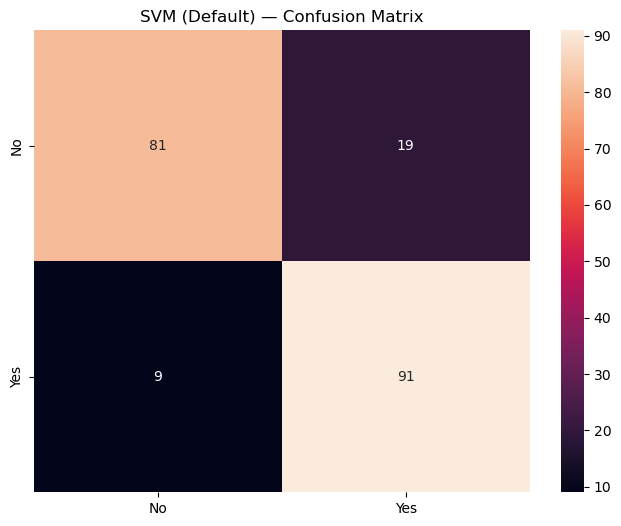

In [208]:
# =====================================================================
#                  GENERATE DIAGNOSTIC VISUALIZATION
# =====================================================================

# Calculate residuals
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_processed, y_predict_svm),
            annot=True, fmt='d',xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("SVM (Default) — Confusion Matrix")
plt.show()

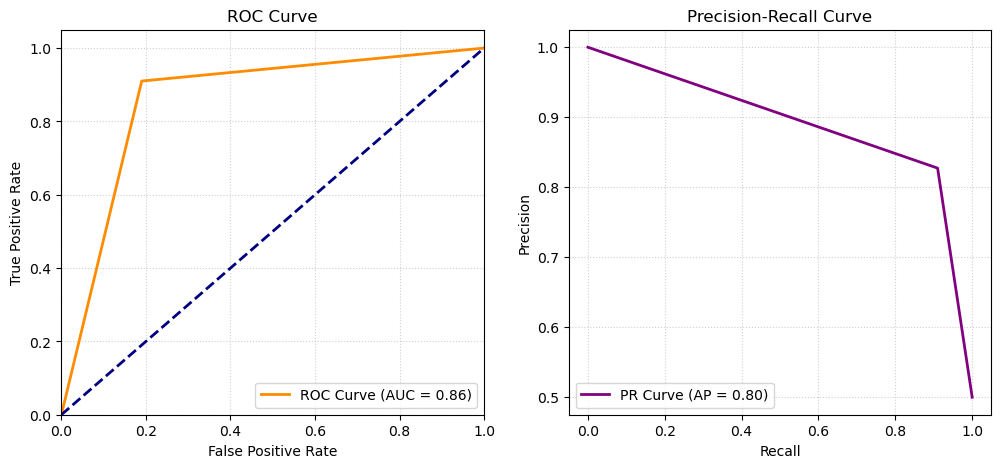

<Figure size 640x480 with 0 Axes>

In [209]:
fig,axis = plt.subplots(nrows=1,ncols=2,figsize=(12,5))
# Get the predicted probabilities for the positive class (Class 1)
# y_scores come from model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_processed, y_predict_svm)
roc_auc = roc_auc_score(y_test_processed, y_predict_svm)

# Plot ROC curve
plt.figure()
axis[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axis[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random guess line
axis[0].set_xlim([0.0, 1.0])
axis[0].set_ylim([0.0, 1.05])
axis[0].set_xlabel('False Positive Rate')
axis[0].set_ylabel('True Positive Rate')
axis[0].set_title('ROC Curve')
axis[0].legend(loc="lower right")
axis[0].grid(True, linestyle=':', alpha=0.6)

# Calculate precision and recall across thresholds
precision, recall, thresholds = precision_recall_curve(y_test_processed, y_predict_svm)
avg_precision = average_precision_score(y_test_processed, y_predict_svm)

# Plot Precision-Recall curve
axis[1].plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AP = {avg_precision:.2f})')
axis[1].set_xlabel('Recall')
axis[1].set_ylabel('Precision')
axis[1].set_title('Precision-Recall Curve')
axis[1].legend(loc="lower left")
axis[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### SVM (Tuned)

In [210]:
print(gscv_svm_model.best_params_)
print(gscv_svm_model.best_score_,end='\n\n')

print("--- Detailed Classification Report ---")
print(classification_report(y_test_processed, y_predict_gscv_svm))
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test_processed, y_predict_gscv_svm),end='\n\n')
print(f"Accuracy Score : {accuracy_score(y_true=y_test_processed,y_pred=y_predict_gscv_svm):.2f}")
print(f"Precision Score : {precision_score(y_true=y_test_processed,y_pred=y_predict_gscv_svm):.2f}")
print(f"F1 Score : {f1_score(y_true=y_test_processed,y_pred=y_predict_gscv_svm):.2f}")

{'svm_model__C': 1, 'svm_model__gamma': 'scale', 'svm_model__kernel': 'rbf'}
0.8775000000000001

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       100
           1       0.83      0.91      0.87       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200

--- Confusion Matrix ---
[[81 19]
 [ 9 91]]

Accuracy Score : 0.86
Precision Score : 0.83
F1 Score : 0.87


### Plot the predictions of SVM (Tuned)

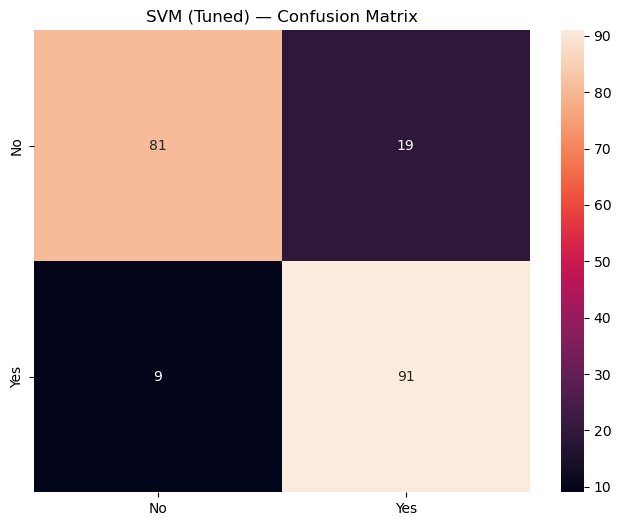

In [211]:
# =====================================================================
#                  GENERATE DIAGNOSTIC VISUALIZATION
# =====================================================================

# Calculate residuals
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_processed, y_predict_gscv_svm),
            annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("SVM (Tuned) — Confusion Matrix")
plt.show()

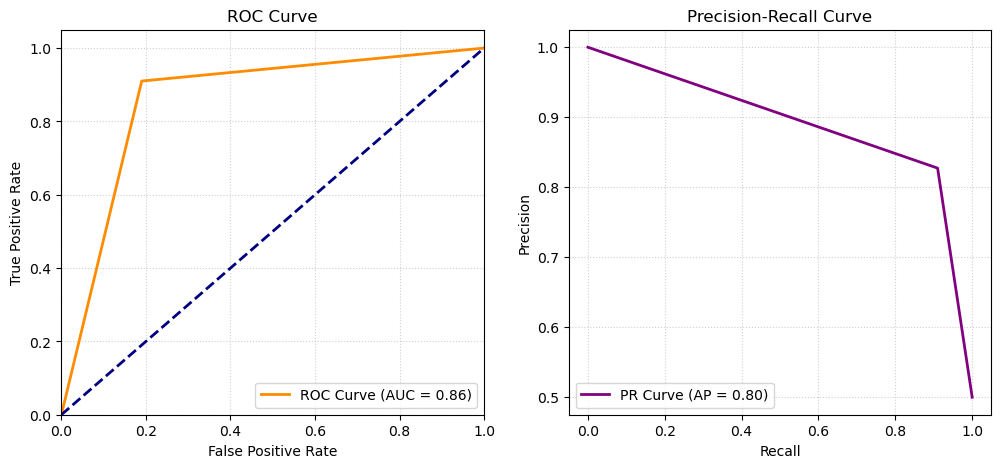

<Figure size 640x480 with 0 Axes>

In [212]:
fig,axis = plt.subplots(nrows=1,ncols=2,figsize=(12,5))
# Get the predicted probabilities for the positive class (Class 1)
# y_scores come from model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_processed, y_predict_gscv_svm)
roc_auc = roc_auc_score(y_test_processed, y_predict_gscv_svm)

# Plot ROC curve
plt.figure()
axis[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axis[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random guess line
axis[0].set_xlim([0.0, 1.0])
axis[0].set_ylim([0.0, 1.05])
axis[0].set_xlabel('False Positive Rate')
axis[0].set_ylabel('True Positive Rate')
axis[0].set_title('ROC Curve')
axis[0].legend(loc="lower right")
axis[0].grid(True, linestyle=':', alpha=0.6)

# Calculate precision and recall across thresholds
precision, recall, thresholds = precision_recall_curve(y_test_processed, y_predict_gscv_svm)
avg_precision = average_precision_score(y_test_processed, y_predict_gscv_svm)

# Plot Precision-Recall curve
axis[1].plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AP = {avg_precision:.2f})')
axis[1].set_xlabel('Recall')
axis[1].set_ylabel('Precision')
axis[1].set_title('Precision-Recall Curve')
axis[1].legend(loc="lower left")
axis[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

* SVM (Default) is best to use in Predictions from the best two

## EXPORT THE SAVED MODEL FILE

In [213]:
# =====================================================================
#                       EXPORT THE SAVED MODEL FILE
# =====================================================================
model_filename = 'saved_models/final_svm_model.pkl'
joblib.dump({'model': svm_model_pipeline, 'label_encoder': le}, model_filename)
print(f"\nSuccess! Model deployed to: '{model_filename}'")


Success! Model deployed to: 'saved_models/final_svm_model.pkl'


## HOW TO LOAD AND RUN ON UNSEEN DATA

In [214]:
# =====================================================================
#                 HOW TO LOAD AND RUN ON UNSEEN DATA
# =====================================================================
# To make future predictions using this file in another script:

# 1. Load the production-ready file
model_loaded = joblib.load("saved_models/final_svm_model.pkl")

# 2. Gather raw, fresh data (Must have the exact same original columns as X)
new_data = pd.DataFrame(
    [{
    'age':55,'gender':'Male','glucose_mg_dl':75,'cholesterol_mg_dl':200,'systolic_bp':130,'smoking':'No',
    'bmi':25.0,'alcohol_consumption':'No','physical_activity':'High','family_history':'No'
},{
    'age':55,'gender':'Male','glucose_mg_dl':105,'cholesterol_mg_dl':250,'systolic_bp':150,'smoking':'Yes',
    'bmi':35.5,'alcohol_consumption':'Yes','physical_activity':'Low','family_history':'No'
}]
)

# 3. Generate instant predictions (The model pipeline handles scaling/encoding internally)
predictions = model_loaded['model'].predict(new_data)
# print(predictions)
print(model_loaded['label_encoder'].inverse_transform(predictions))
print(f"\nSuccess! Saved deployment-ready model to: '{model_filename}'")

['No' 'Yes']

Success! Saved deployment-ready model to: 'saved_models/final_svm_model.pkl'
